#  Bài tâp về mạng tích chập

Trong bài này, chúng ta sẽ xây dựng một mạng tích chập sử dụng torch và thử train&test với tập MNIST nhé.


## Tổng quan một mạng CNN cơ bản

![CNN](http://personal.ie.cuhk.edu.hk/~ccloy/project_target_code/images/fig3.png)

## MNIST dataset

Trong bài tập này, chúng ta sẽ sử dựng tập MNIST rất nổi tiếng vể  các chữ số viết tay từ 0->9. Tập dataset này bao gồm 60000 ảnh cho training và 10000 ảnh cho testing. Các bức ảnh này đều đã được căn giữa và chỉnh với kích thước cố định là 28x28.

Trong phần tiền xử lý, chúng ta sẽ cần chuẩn hóa các giá trị pixel của mỗi ảnh về khoảng [0,1], kiểu dữ liệu sẽ là float32

<!-- ![MNIST Dataset](http://neuralnetworksanddeeplearning.com/images/mnist_100_digits.png) -->

Chi tiết tại: http://yann.lecun.com/exdb/mnist/

# Some configs

- Chúng ta sẽ setup một số hyper-parameters cũng như một số giá trị cần dùng theo hướng dẫn nhé
- Ở đây, mình muốn các bạn sử dụng Cuda, hãy vào runtime, rồi change the runtime type sang GPU nhé 

In [ ]:
# Trước hết, chúng ta import một số thư viện cần thiết đã
import torch
import torch.nn as nn   # nn la module chua cac cong cu de xay dung neural network
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
import random

In [3]:
# Thiết lập thiết bị mặc định
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Thiết bị đang sử dụng: {device}")

Thiết bị đang sử dụng: cuda


In [7]:
# Số classes trong tập MNIST
num_classes = 10 # tuc la so lop can phan loai

# Số epoch - la so lan model hoc qua toan bo tap du lieu train
epochs = 6

# Các tham số cần thiết cho quá trình training
learning_rate = 0.001 # toc do hoc
batch_size = 64   # so luong anh duoc dua vao model trong 1 lan cap nhat trong so
display_step = 100 # 

# Path lưu best model 
checkpoint = "mnist_best_model.pth" # có thể để dạng *.pth

# device chúng ta dùng cuda
device = 'cuda' if torch.cuda.is_available() else 'cpu'
assert device == 'cuda' 

# Dataloader


In [8]:
# Transform image 
transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) 
    ])

# load dataset từ torchvision.datasets
# transform = transform de ap dung cac phep bien doi tren anh
train_dataset = datasets.MNIST('../data', train=True, download=True,transform=transform)
test_dataset = datasets.MNIST('../data', train=False,transform=transform)

# shuffle = true de tron du lieu, giup model hoc tot hon
train_loader = torch.utils.data.DataLoader(train_dataset,batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset,batch_size=batch_size, shuffle=False)

# Model

- Trong bài này, chúng ta sẽ định nghĩa một class Net, nó sẽ có cấu trúc như hình ở đầu notebook
- Bạn hãy chỉnh các tham số cho phù hợp nhé :) 

In [14]:
class Net(nn.Module):
  def __init__(self):

    super(Net,self).__init__()
    self.dropout = nn.Dropout()
    self.relu = nn.ReLU()

    # cong thuc cua conv2d: nn.Conv2d(in_channels, out_channels, kernel_size, stride)
    # in channels la so kenh mau dau vao, out channels la so kenh dau ra, kernel size la kich thuoc cua bo loc, stride la buoc nhay cua bo loc
    self.conv1 = nn.Conv2d(1,32,3,1)
    # do MNIST la anh xam voi kich thuoc 1x28x28 nen in_channels = 1
    # out_channels = 32 la so kenh dau ra, so luong thi tuy chon nma thuong doi voi cnn nho thi so 32 la pho bien
    # kernel_size = 3 la kich thuoc cua bo loc, tuc la bo loc se duoc ap dung tren moi vung 3x3 cua anh dau vao
    # stride = 1 la buoc nhay cua bo loc, tuc la bo loc se duoc ap dung tren moi vung 3x3 cua anh dau vao va di chuyen 1 pixel moi lan
    # Ket qua nhan duoc sau conv1 la 32 kenh mau voi kich thuoc 26x26, vi bo loc 3x3 se giam kich thuoc cua anh sau khi qua conv1 xuong 2 pixel o moi chieu, tuc la tu 28x28 xuong 26x26

    self.maxpool1 = nn.MaxPool2d(2)
    # maxpool2d(2) se giam kich thuoc cua anh sau khi qua conv1 xuong 1 nua. Lay vung 2x2 roi giu lai gia tri lon nhat, tuc la tu 32x26x26 xuong 32x13x13

    self.conv2 = nn.Conv2d(32,64,3,1)
    # Sau khi qua maxpool1, kich thuoc cua anh la 32 kenh mau voi kich thuoc 13x13, nen in_channels = 32
    # out_channels = 64 la so kenh dau ra, so luong thi tuy chon nma thuong doi voi cnn nho thi so 64 la pho bien. Cang ve sau. model thuong tang so luong kenh len de hoc dac trung phuc tap hon
    # Sau conv2, 32x13x13 -> 64x11x11


    self.maxpool2 = nn.MaxPool2d(2)
    # maxpool2d(2) se giam kich thuoc cua anh sau khi qua conv2 xuong 1 nua. Lay vung 2x2 roi giu lai gia tri lon nhat, tuc la tu 64x11x11 xuong 64x5x5 (maxpool tu dong lay phan nguyen)
    
    
    self.conv3 = nn.Conv2d(64,128,3,1)
    # sau conv3, 64x5x5 -> 128x3x3

    self.maxpool3 = nn.MaxPool2d(2)
    # maxpool2d(2) se giam kich thuoc cua anh sau khi qua conv3 xuong 1 nua. Lay vung 2x2 roi giu lai gia tri lon nhat, tuc la tu 128x3x3 xuong 128x1x1 (maxpool tu dong lay phan nguyen)
    


    # sau 3 tang conv + maxpool, anh khong con la 2D nua ma da duoc rut gon thanh 1 vector dac trung
    # Cac tang Linear de tong hop dac trung va dua ra du doan cuoi cung
    self.fc1 = nn.Linear(128,128)
    # Linear(128, 128) khong giu nguyen 128 dac trung cu, no tao ra 128 dac trung moi, moi dac trung la mot ket hop phi tuyen tinh cua cac dac trung cu, giup mo hinh hoc duoc nhung dac trung phuc tap hon

    self.fc2 = nn.Linear(128,64)
    self.fc3 = nn.Linear(64,num_classes)

  # Doan nay la qua trinh forward, tuc la qua trinh du lieu di qua cac tang cua mo hinh de ra du doan cuoi cung
  # No se mo ta anh dau vao x se di qua model theo thu tu nhu the nao
  # Ta can forward vi trong __init__, ta moi chi khai bao cac tang, chua xac dinh du lieu se di qua cac tang nhu the nao, do do ta can forward de xac dinh du lieu se di qua cac tang nhu the nao
  def forward(self,x):
    x = self.conv1(x)
    x = self.relu(x)
    x = self.maxpool1(x)

    x = self.conv2(x)
    x = self.relu(x)
    x = self.maxpool2(x)

    x = self.conv3(x)
    x = self.relu(x)
    x = self.maxpool3(x)

    x = torch.flatten(x, 1)

    x = self.fc1(x)
    x = self.relu(x)
    x = self.dropout(x)

    x = self.fc2(x)
    x = self.relu(x)
    x = self.dropout(x)

    x = self.fc3(x)
    return x

In [15]:
# call model, đừng quên set device nhé
# Net() de tao model, .to(device) de chuyen model len GPU
model = Net().to(device)

# load lại pretrained model (nếu có)
# Tuc la doan nay dang co load model da train san tu file checkpoint
try:
  model.load_state_dict(torch.load(checkpoint))
  print("Loaded checkpoint successfully!")
except:
  print("!!! Hãy train để có checkpoint file")

!!! Hãy train để có checkpoint file


In [16]:
criterion = nn.NLLLoss()
# NLLLoss() la ham mat mat dung cho bai toan phan loai nhieu lop (Negative Log Likelihood Loss) - HIEU DON GIAN la no do xem model du doan sai nhieu hay it

optimizer = optim.Adam(model.parameters(), lr=learning_rate) # dung de cap nhat trong so cua model
# Adam la mot thuat toan toi uu duoc su dung pho bien trong deep learning, no tu dong dieu chinh toc do hoc cho moi tham so, giup mo hinh hoc nhanh hon va tot hon
best_val_loss = 999 # current best test loss

for epoch in range(1,epochs + 1):
    # Quá trình training 
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad() # zero_grad(), xoa gradient cu do gradient se cong don qua cac lan backward()
        output = model(data) # dong nay goi ham forward() ben trong class Net
        # Tuc la anh di qua: Conv → ReLU → MaxPool → Flatten → Linear → output
        
        
        output = F.log_softmax(output, dim=1)
        # bien logits thanh log-xac xuat cho tung class
        # dim=1 vi voi MNIST, moi anh co 10 class, nen dum=1 chinh la chieu chua 10 diem so do

        loss = criterion(output, target) # tinh loss, so sanh output voi target
        loss.backward() # lan truyen nguoc de tinh gradient
        optimizer.step() # cap nhat trong so cua model
        # in thong tin training
        if batch_idx % display_step == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tTrain Loss: {:.6f}'.format(
                epoch, batch_idx * len(data), len(train_loader.dataset),
                100. * batch_idx / len(train_loader), loss.item()))
    
    
    # Quá trình testing, chuyen sang che do test 
    model.eval() # bao cho model biet bay gio dang danh gia
    test_loss = 0
    correct = 0


    # set no grad cho quá trình testing
    # Khi test thi chi can du doan nen khong can cap nhat trong so
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)

            output = model(data)
            output = F.log_softmax(output, dim=1)

            # tinh cong don loss cua batch test roi cong vao test_loss
            test_loss += F.nll_loss(output, target, reduction='sum').item()

            pred = output.argmax(dim=1, keepdim=True)

            correct += pred.eq(target.view_as(pred)).sum().item()

    test_loss /= len(test_loader.dataset)

    if test_loss < best_val_loss:
      best_val_loss = test_loss
      torch.save(model.state_dict(), checkpoint)
      print("***********    TEST_ACC = {}%    ***********".format(
          100. * correct / len(test_loader.dataset)
      ))

Train Epoch: 1 [0/60000 (0%)]	Train Loss: 2.316176
Train Epoch: 1 [6400/60000 (11%)]	Train Loss: 1.016299
Train Epoch: 1 [12800/60000 (21%)]	Train Loss: 0.492763
Train Epoch: 1 [19200/60000 (32%)]	Train Loss: 0.441604
Train Epoch: 1 [25600/60000 (43%)]	Train Loss: 0.266103
Train Epoch: 1 [32000/60000 (53%)]	Train Loss: 0.293469
Train Epoch: 1 [38400/60000 (64%)]	Train Loss: 0.194508
Train Epoch: 1 [44800/60000 (75%)]	Train Loss: 0.267407
Train Epoch: 1 [51200/60000 (85%)]	Train Loss: 0.296154
Train Epoch: 1 [57600/60000 (96%)]	Train Loss: 0.116554
***********    TEST_ACC = 97.37%    ***********
Train Epoch: 2 [0/60000 (0%)]	Train Loss: 0.258524
Train Epoch: 2 [6400/60000 (11%)]	Train Loss: 0.250776
Train Epoch: 2 [12800/60000 (21%)]	Train Loss: 0.090159
Train Epoch: 2 [19200/60000 (32%)]	Train Loss: 0.365280
Train Epoch: 2 [25600/60000 (43%)]	Train Loss: 0.175279
Train Epoch: 2 [32000/60000 (53%)]	Train Loss: 0.232686
Train Epoch: 2 [38400/60000 (64%)]	Train Loss: 0.140787
Train Epoch:

In [17]:
# load lại model đã train (tuc la model tot nhat da duoc luu trong checkpoint .pth)
model.load_state_dict(torch.load(checkpoint))

# Set eval phase nhé bạn
model.eval() # chuyen model sang che do danh gia

Net(
  (dropout): Dropout(p=0.5, inplace=False)
  (relu): ReLU()
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (maxpool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (maxpool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
  (maxpool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=128, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
)

In [18]:
item = iter(test_loader)

In [20]:
data,target = next(item) # lấy một batch ra

In [21]:
test_idx = random.choice(range(len(data))) # lấy index của một phần tử của một batch

In [22]:
data = data[test_idx]
target = target[test_idx]
assert data.shape == (1,28,28)

In [25]:
# thử predict 

def plot(data,model):
  data = data.unsqueeze(0).to(device) # unsqueeze data, đồng thời set device
  # unsqueeze de them 1 chieu vao data, vi model can du lieu co dang (batch_size, channels, height, width), ma data dang co dang (channels, height, width), nen can unsqueeze de them chieu batch_size = 1 vao data, tuc la tu (1,28,28) xuong (1,1,28,28)
  output = model(data) 
  output = F.log_softmax(output, dim=1) # log softmax, chú ý dim
  pred = output.argmax(dim=1, keepdim=True) # argmax, chú ý keepdim 
  print("Predict Number : ", pred[0][0].detach().cpu().numpy()) 
  plt.imshow(data[0][0].detach().cpu().numpy(),cmap='gray') 
  plt.show()

Predict Number :  0


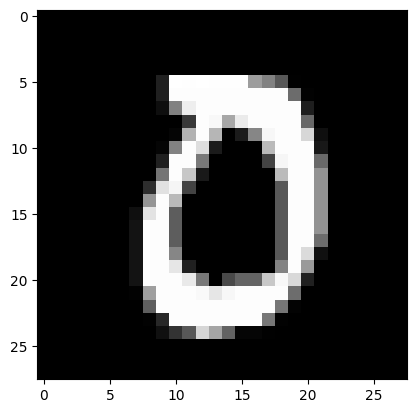

In [26]:
plot(data,model)